In [ ]:
cd ../..

/


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install matplotlib_scalebar

In [3]:
import numpy as np
# 兼容补丁 / Compatibility patch
if not hasattr(np, "int"):
  np.int = int

In [4]:
import sys, os
save_dir = '/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/results/Recon_InP_CuCrS2P6_71/'
os.makedirs(save_dir, exist_ok=True)
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path:", PROJECT_ROOT)

print("Project root content:", os.listdir(PROJECT_ROOT))

Added to sys.path: /content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D
Project root content: ['Notebooks', 'data', 'Magnetisation']


In [16]:
from Magnetisation.Propagator import Propagator
from Magnetisation.Generator import generator_CNN
from Magnetisation.Train import Magnetisation_CNN_training
from Magnetisation.utils import LoadData

import numpy as np
import json
import torch
import matplotlib.pyplot as plt

[[ 6.43800663e-06 -1.51398122e-06  7.75175617e-06 ...  4.80575098e-06
   1.47345660e-05  5.52415457e-06]
 [ 2.76321054e-06  1.30086373e-05  9.88463066e-06 ...  1.24581061e-05
   1.57336136e-05 -1.09360202e-05]
 [ 8.01682606e-06 -1.27954262e-05  1.12813125e-05 ... -1.46688703e-05
   1.38481580e-05 -1.35373999e-05]
 ...
 [-4.66971070e-06 -2.13538114e-05  2.80909317e-05 ... -1.41638310e-05
  -3.12957059e-06 -6.88273632e-06]
 [ 1.16035630e-05 -2.08798107e-05 -2.15982115e-05 ...  9.74416693e-06
  -8.85502131e-06 -1.32571300e-05]
 [-4.24575860e-05 -3.03823173e-05  2.61122493e-05 ... -9.71164849e-06
   9.51822064e-06 -3.60445530e-05]]
[[ 6.43800663e-06 -1.51398122e-06  7.75175617e-06 ...  4.80575098e-06
   1.47345660e-05  5.52415457e-06]
 [ 2.76321054e-06  1.30086373e-05  9.88463066e-06 ...  1.24581061e-05
   1.57336136e-05 -1.09360202e-05]
 [ 8.01682606e-06 -1.27954262e-05  1.12813125e-05 ... -1.46688703e-05
   1.38481580e-05 -1.35373999e-05]
 ...
 [-4.66971070e-06 -2.13538114e-05  2.8090931

{'PixelSize': 4.8e-07,
 'ImageShape': 256,
 'NV': {'Height': 3e-07,
  'Theta': 0,
  'FindTheta': False,
  'Phi': 0,
  'FindPhi': False},
 'Magnetisation': {'Phi': -45,
  'FindPhi': False,
  'Theta': 88,
  'FindTheta': False},
 'FFT': {'PaddingFactor': 2,
  'performPadding': False,
  'PaddingMode': 'constant',
  'Extended': False,
  'Extention': 100,
  'Filter': {'useHanning': False,
   'useHighCutoff': False,
   'useLowCutoff': False,
   'LambdaHighCutoff': 1e-07,
   'LambdaLowCutoff': 7e-06}}}

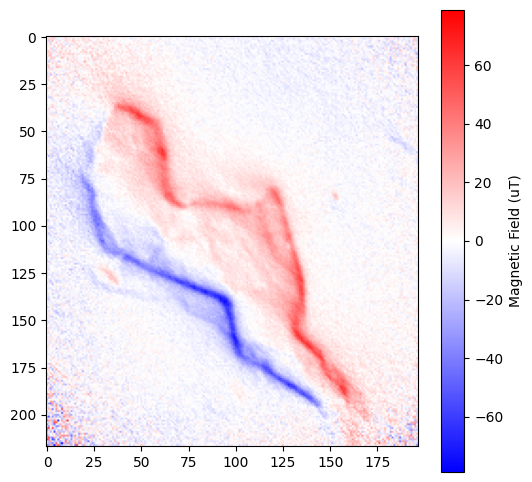

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Load data
dataPath='/content/drive/MyDrive/Colab Notebooks/MR MCD Pipeline/2D/data/Magnetisation in plane/CuCrP2S6_unimelb_measurement_71_Bnv.json'
PROP = LoadData(dataPath, ImageShape = 256, Normalise=True, Display=True)

# Update some of the options
PROP.options['Magnetisation']['Theta']= 88
PROP.options['Magnetisation']['FindTheta']= False
PROP.options['Magnetisation']['Phi'] = -45
PROP.options['Magnetisation']['FindPhi']= False
display(PROP.options)

In [18]:
# Make the neural network
Generator = generator_CNN(Size=1, ImageSize=PROP.options['ImageShape']).to(device)

In [19]:
# Set the machine learning paramaters for keyword unpacking
ML_options = dict()
ML_options['mlp']=False
ML_options['LossFunction']='L1'
ML_options['Magnetization']=None
ML_options['IntegerOnly']=False
ML_options['PositiveMagnetisationOnly']=True
ML_options['PrintLossValue']=False
ML_options['Epochs']= 300

100%|██████████| 300/300 [00:45<00:00,  6.65it/s]


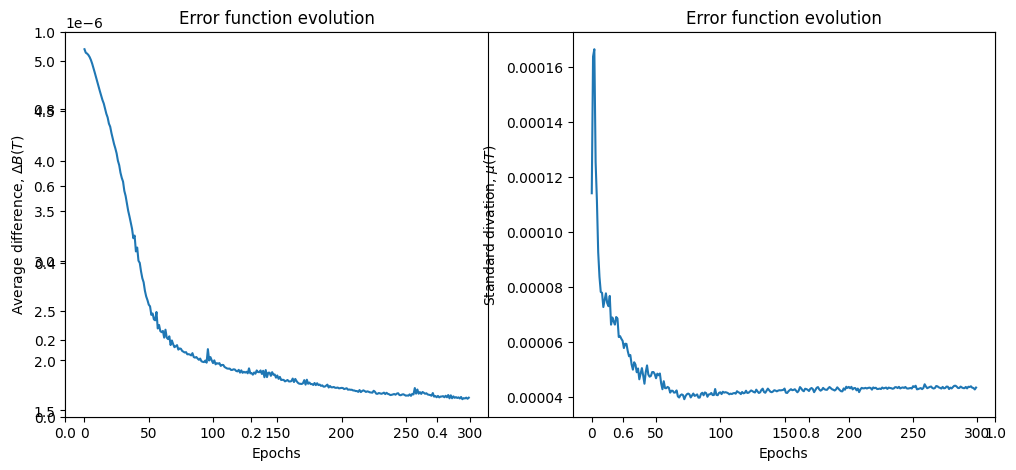

In [20]:
# Train the network
CNN_training = Magnetisation_CNN_training(device, Generator, PROP,ML_options)
bnv_cnn = CNN_training.train_cnn(**ML_options)
plt.savefig(save_dir + '2_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

Final MagnetisationMap shape: (256, 256)
Final ReconstructedBnv shape: (256, 256)


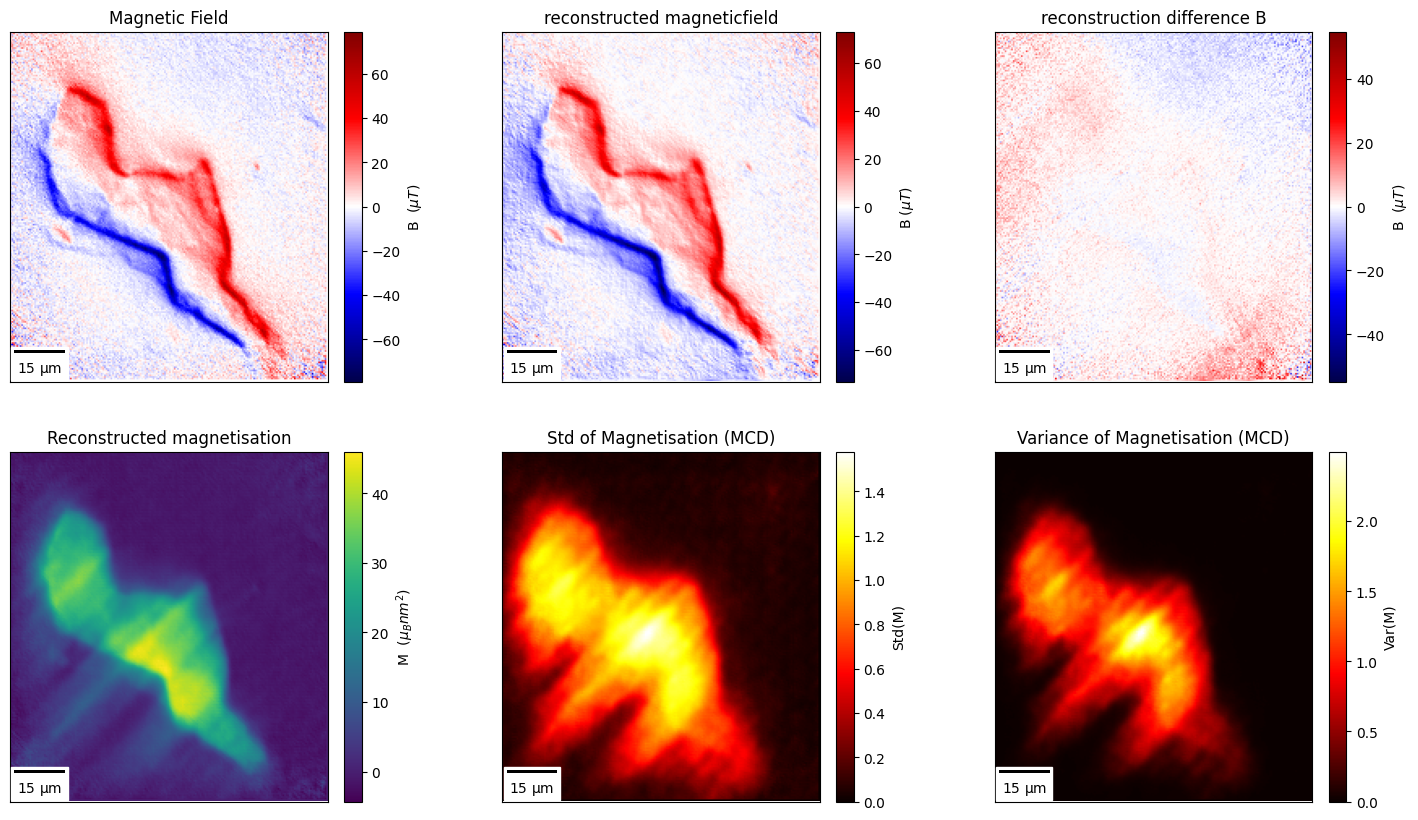

In [21]:
# Get the results and plot
Results = CNN_training.extract_results(plotResults = True)
plt.savefig(save_dir + '3_reconstruction_results.png', dpi=300, bbox_inches='tight')
plt.show()

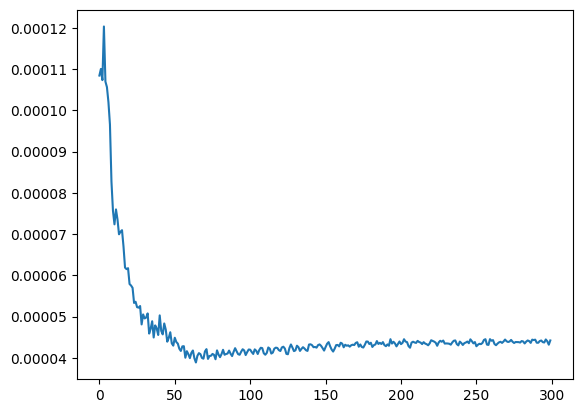

In [11]:
plt.plot(Results['Errors']['SNR'])